In [46]:
#-----Importing and reading the csv-----#

import pandas as pd
import numpy as np
import time
import tracemalloc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


#-------------READING THE CSV AND PRINTING THE FIRST 5 ROWS-----------#
data_df = pd.read_csv("waterquality.csv")

# head() prints the first five rows only
print(data_df.head())

         Date  Salinity (ppt)  DissolvedOxygen (mg/L)   pH  SecchiDepth (m)  \
0  11-05-1989             NaN                     NaN  7.5              0.3   
1  18-05-1989             NaN                    12.0  7.5              0.2   
2  25-05-1989             NaN                     NaN  8.0              0.4   
3  01-06-1989             NaN                    12.0  8.0              0.4   
4  11-07-1989             NaN                     NaN  8.5              0.3   

   WaterDepth (m)  WaterTemp (C)  AirTemp (C)  
0             0.9           17.0   -17.777778  
1             0.6           17.5    20.500000  
2             0.8           23.0    25.000000  
3             0.9           25.5    29.000000  
4             0.9           28.5    28.000000  


In [47]:

#-------- MULTIPLE LINEAR REGRESSION --------#

data_df = pd.read_csv("waterquality.csv")

# Defining the dependent and independent variables
INDEPENDENT_VARIABLES = ["Salinity (ppt)", "pH", "SecchiDepth (m)", "WaterDepth (m)", "WaterTemp (C)", "AirTemp (C)"]
DEPENDENT_VARIABLE = ["DissolvedOxygen (mg/L)"]

# The NA values have to be removed before proceeding with the regression
# total count of data before dropping missing values
count_before = len(data_df)

# Dropping missing values
data_df = data_df.dropna(subset=DEPENDENT_VARIABLE +INDEPENDENT_VARIABLES).reset_index(drop=True)

# total count of data after dropping the missing values
count_after = len(data_df)

# Assiging X and Y
y=data_df[DEPENDENT_VARIABLE]
X=data_df[INDEPENDENT_VARIABLES]

print("Independent variables: ",INDEPENDENT_VARIABLES)
print("Dependent variables: ",DEPENDENT_VARIABLE)
print("\n")
print("Total data points before dropping the missing values: ", count_before)
print("Total data points after dropping the missing values: ", count_after)

# Splitting into training and testing sets (80% training, 20% testing)
# Random_state -> to fix the randomness
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

print("\n")
print("Training size: ", len(X_train))
print("Testing size: ", len(X_test))

# Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training MLR
mlr = LinearRegression()
mlr.fit(X_train_scaled, y_train)

y_pred_mlr = mlr.predict(X_test_scaled)

# ----------------------------Calculating the metrics--------------------------#

# Calculating RMSE, MAE and R2
r2_mlr = r2_score(y_test, y_pred_mlr)
rmse_mlr = np.sqrt(mean_squared_error(y_test, y_pred_mlr))
mae_mlr = mean_absolute_error(y_test, y_pred_mlr)


# Calculating the fit time (how long the model takes to learn from the training data) 
# and predict time (how long the trained model takes to prodce the predictions for new data)

t_start = time.perf_counter()
mlr.fit(X_train_scaled, y_train)
fit_time_mlr = time.perf_counter() - t_start

t_start = time.perf_counter()
y_pred_mlr = mlr.predict(X_test_scaled)
predict_time_mlr = time.perf_counter() - t_start


# Calculating Peak Memory (max amount of RAM used by the code)
mlr_model = LinearRegression()

tracemalloc.start()
mlr_model.fit(X_train_scaled, y_train)
mlr_fit_mem = tracemalloc.get_traced_memory()[1] / 1024
tracemalloc.stop()

tracemalloc.start()
mlr_model.predict(X_test_scaled)
mlr_pred_mem = tracemalloc.get_traced_memory()[1] / 1024
tracemalloc.stop()


print("\n")
print("Multiple Linear Regression Metrics: ")
print("R2 score for MLR: ",r2_mlr)
print("RMSE for MLR: ", rmse_mlr)
print("MAE for MLR: ",mae_mlr)
print("\n")
print("Fit time for MLR: ",fit_time_mlr)
print("Predict time for MLR: ",predict_time_mlr)
print("\n")
print("Fit peak memory: ",mlr_fit_mem)
print("Predict peak memory: ",mlr_pred_mem)

Independent variables:  ['Salinity (ppt)', 'pH', 'SecchiDepth (m)', 'WaterDepth (m)', 'WaterTemp (C)', 'AirTemp (C)']
Dependent variables:  ['DissolvedOxygen (mg/L)']


Total data points before dropping the missing values:  2371
Total data points after dropping the missing values:  1320


Training size:  1056
Testing size:  264


Multiple Linear Regression Metrics: 
R2 score for MLR:  0.36326870772032727
RMSE for MLR:  1.9987286006955516
MAE for MLR:  1.5191905108404051


Fit time for MLR:  0.0025382000021636486
Predict time for MLR:  0.0004115002229809761


Fit peak memory:  129.671875
Predict peak memory:  12.1328125


In [42]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

# ---------- K-NEAREST NEIGHBOURHOOD REGRESSION ---------- #

# Finding the best k value
param_grid = {"n_neighbors": range(1, 51)}
knnr = KNeighborsRegressor()

# GridSearchCV -> used to find the best k
# cv=5 -> It trains on the 4 parts, tests on the remaining 1
# scoring="r2" -> R2 is used to compare
grid_search = GridSearchCV(
    estimator=knnr,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid_search.fit(X_train_scaled, y_train)

best_k = grid_search.best_params_["n_neighbors"]
best_cv_r2 = grid_search.best_score_

# Train the final KNNR model using the best k
knn_final = KNeighborsRegressor(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_knn = knn_final.predict(X_test_scaled)


# ----------------------------Calculating the metrics--------------------------#

# Calculating RMSE, MAE and R2
r2_knn = r2_score(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn = mean_absolute_error(y_test, y_pred_knn)


# Calculating the fit and predict time
t_start = time.perf_counter()
knn_final.fit(X_train_scaled, y_train)
fit_time_knn = time.perf_counter() - t_start

t_start = time.perf_counter()
y_pred_knn = knn_final.predict(X_test_scaled)
predict_time_knn = time.perf_counter() - t_start


# Calculating Peak Memory
knnr_model = KNeighborsRegressor()

tracemalloc.start()
knnr_model.fit(X_train_scaled, y_train)
knnr_fit_mem = tracemalloc.get_traced_memory()[1] / 1024
tracemalloc.stop()

tracemalloc.start()
knnr_model.predict(X_test_scaled)
knnr_pred_mem = tracemalloc.get_traced_memory()[1] / 1024
tracemalloc.stop()


print("\n")
print("KNNR Results for (k =", best_k, ")")
print("R2 score: ", r2_knn)
print("RMSE for KNNR: ", rmse_knn)
print("MAE for KNNR: ", mae_knn)
print("\n")
print("Fit time for KNNR: ",fit_time_knn)
print("Predict time for KNNR: ",predict_time_knn)
print("\n")
print("Fit peak memory: ",knnr_fit_mem)
print("Predict peak memory: ",knnr_pred_mem)



KNNR Results for (k = 13 )
R2 score:  0.4572484837140842
RMSE for KNNR:  1.8453393927537092
MAE for KNNR:  1.4047377622377621


Fit time for KNNR:  0.003004500176757574
Predict time for KNNR:  0.005121299996972084


Fit peak memory:  82.1904296875
Predict peak memory:  58.00390625


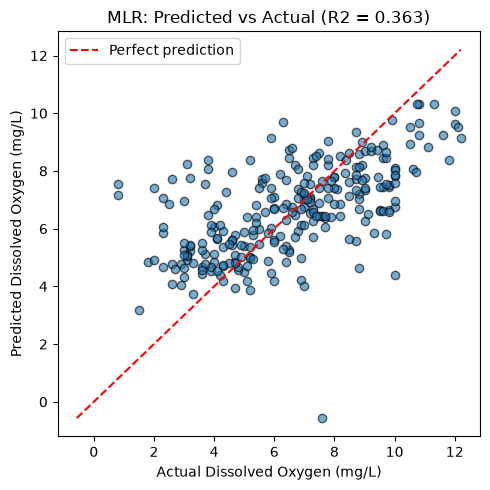

In [40]:
#------------- MLR: Predicted vs Actual Graph ------------#

import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_mlr, alpha=0.6, edgecolor="k")
lims = [min(y_test.values.min(), y_pred_mlr.min()), max(y_test.values.max(), y_pred_mlr.max())]

plt.plot(lims, lims, "r--", label="Perfect prediction")

plt.xlabel("Actual Dissolved Oxygen (mg/L)")
plt.ylabel("Predicted Dissolved Oxygen (mg/L)")
plt.title(f"MLR: Predicted vs Actual (R2 = {r2_mlr:.3f})")
plt.legend()

plt.tight_layout()
plt.savefig("mlr_predicted_vs_actual.png", dpi=300)
plt.show()

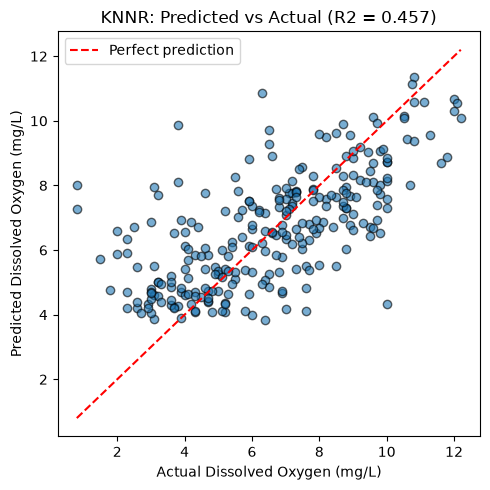

In [41]:
#------------- KNNR: Predicted vs Actual Graph ------------#

import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_knn, alpha=0.6, edgecolor="k")
lims = [min(y_test.values.min(), y_pred_knn.min()), max(y_test.values.max(), y_pred_knn.max())]

plt.plot(lims, lims, "r--", label="Perfect prediction")

plt.xlabel("Actual Dissolved Oxygen (mg/L)")
plt.ylabel("Predicted Dissolved Oxygen (mg/L)")
plt.title(f"KNNR: Predicted vs Actual (R2 = {r2_knn:.3f})")
plt.legend()

plt.tight_layout()
plt.savefig("knnr_predicted_vs_actual.png", dpi=300)
plt.show()

In [43]:
import pandas as pd

results_df = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE", "Fit time (s)", "Predict time (s)",
               "Fit peak memory (KB)", "Predict peak memory (KB)"],
    "MLR":  [r2_mlr, rmse_mlr, mae_mlr, fit_time_mlr, predict_time_mlr,
             mlr_fit_mem, mlr_pred_mem],
    "KNNR": [r2_knn, rmse_knn, mae_knn, fit_time_knn, predict_time_knn,
             knnr_fit_mem, knnr_pred_mem],
})

print(results_df)
results_df.to_csv("results_comparison.csv", index=False)

                     Metric         MLR       KNNR
0                        R2    0.363269   0.457248
1                      RMSE    1.998729   1.845339
2                       MAE    1.519191   1.404738
3              Fit time (s)    0.003567   0.003005
4          Predict time (s)    0.000507   0.005121
5      Fit peak memory (KB)  129.660156  82.190430
6  Predict peak memory (KB)   12.132812  58.003906


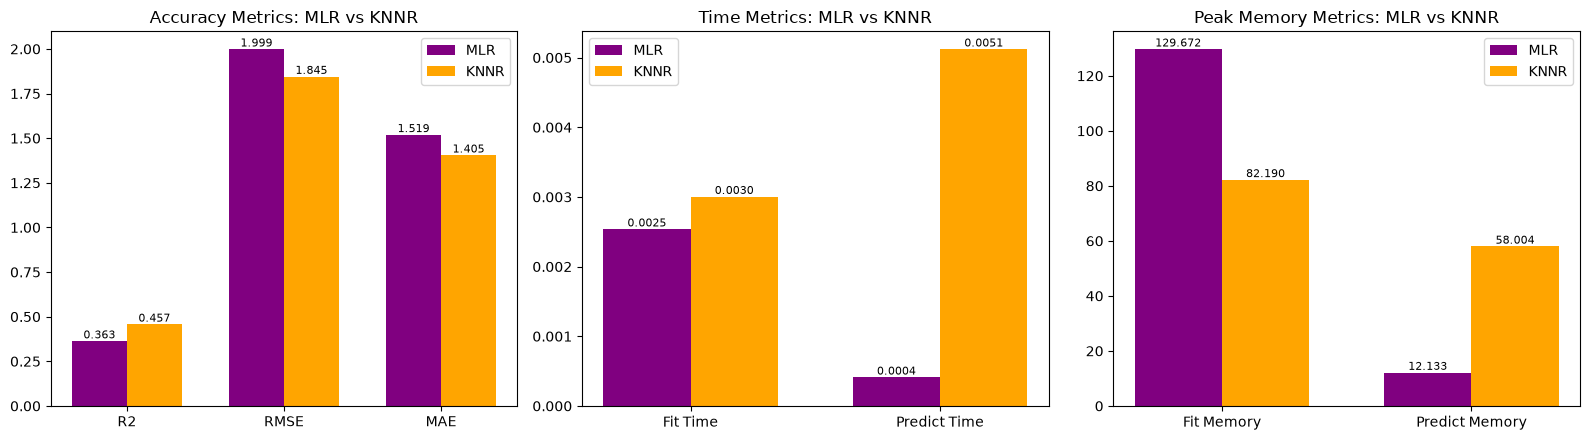

In [51]:
import numpy as np

# Plot size
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
width = 0.35

# Graph 1 - Accuracy Metrics
labels1 = ["R2", "RMSE", "MAE"]
mlr_values1 = [r2_mlr, rmse_mlr, mae_mlr]
knn_values1 = [r2_knn, rmse_knn, mae_knn]
x = np.arange(len(labels1))

bars1 = axes[0].bar(x - width/2, mlr_values1, width, label="MLR", color="purple")
bars2 = axes[0].bar(x + width/2, knn_values1, width, label="KNNR", color="orange")

axes[0].bar_label(bars1, fmt="%.3f", fontsize=8)
axes[0].bar_label(bars2, fmt="%.3f", fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels1)
axes[0].set_title("Accuracy Metrics: MLR vs KNNR")
axes[0].legend()


# Graph 2 - Time Metrics
labels2 = ["Fit Time", "Predict Time"]
mlr_values2 = [fit_time_mlr, predict_time_mlr]
knn_values2 = [fit_time_knn, predict_time_knn]
x = np.arange(len(labels2))

bars1 = axes[1].bar(x - width/2, mlr_values2, width, label="MLR", color="purple")
bars2 = axes[1].bar(x + width/2, knn_values2, width, label="KNNR", color="orange")

axes[1].bar_label(bars1, fmt="%.4f", fontsize=8)
axes[1].bar_label(bars2, fmt="%.4f", fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels2)
axes[1].set_title("Time Metrics: MLR vs KNNR")
axes[1].legend()

# Graph 3 - Peak Memory Metrics
labels3 = ["Fit Memory", "Predict Memory"]
mlr_values3 = [mlr_fit_mem, mlr_pred_mem]
knn_values3 = [knnr_fit_mem, knnr_pred_mem]
x = np.arange(len(labels3))

bars1 = axes[2].bar(x - width/2, mlr_values3, width, label="MLR", color="purple")
bars2 = axes[2].bar(x + width/2, knn_values3, width, label="KNNR", color="orange")

axes[2].bar_label(bars1, fmt="%.3f", fontsize=8)
axes[2].bar_label(bars2, fmt="%.3f", fontsize=8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels3)
axes[2].set_title("Peak Memory Metrics: MLR vs KNNR")
axes[2].legend()

plt.tight_layout()
plt.savefig("comparision_metrics.png", dpi=300)
plt.show()
